<details><summary style="display:list-item; font-size:16px; color:blue;">Jupyter Help</summary>
    
Having trouble testing your work? Double-check that you have followed the steps below to write, run, save, and test your code!
    
[Click here for a walkthrough GIF of the steps below](https://static-assets.codecademy.com/Courses/ds-python/jupyter-help.gif)

Run all initial cells to import libraries and datasets. Then follow these steps for each question:
    
1. Add your solution to the cell with `## YOUR SOLUTION HERE ## `.
2. Run the cell by selecting the `Run` button or the `Shift`+`Enter` keys.
3. Save your work by selecting the `Save` button, the `command`+`s` keys (Mac), or `control`+`s` keys (Windows).
4. Select the `Test Work` button at the bottom left to test your work.

![Screenshot of the buttons at the top of a Jupyter Notebook. The Run and Save buttons are highlighted](https://static-assets.codecademy.com/Paths/ds-python/jupyter-buttons.png)

**Setup**
Run the following cell to import libraries and helper function.

In [1]:
import torch
import torch.nn.functional as F
import math
import numpy as np
import pandas as pd

#### Checkpoint 1/3

Let's now implement the attention mechanism from scratch and apply it to the following text sequence: `"The playful fox chases butterflies"`.

We'll start by creating **Q-vectors** for each token in the sequence.

**A.** We've tokenized the text sequence to the variable `tokens`. Let's initialize random embeddings with size `8` dimensions for each token. Save the embedding size to the variable `d`, then use `torch.randn()` to create the random embeddings, and save the embeddings to the variable `E`.

**B.** Next, let's initialize the weight matrix `Wq` with random weight values using a linear layer with the same dimensions as the embedding size, and without bias parameters. 

**C.** Create the Q-vectors for each token using the weight matrix and save them to the variable `Q`.

Don't forget to run the cell and save the notebook before selecting `Test Work`! Open the `Jupyter Help` toggle at the top of the notebook for more details.

In [2]:
torch.manual_seed(42)
text = "The playful fox chases butterflies"
tokens = ["the", "playful", "fox", "chases", "butterflies"]

## YOUR SOLUTION HERE ##
d = 8
E = torch.randn(len(tokens), d)
Wq = torch.nn.Linear(d, d, bias=False) # Linear layer
Q = Wq(E) # Take the embedding matrix E and transform it into Query vectors using a learned linear layer Wq
# Show output - tokens, embeddings, and Q-vectors
print("Tokens:", tokens)
print("Embedding size:", E.shape)
print("Token Embeddings:\n", E)
print("Q-vectors:", Q)

Tokens: ['the', 'playful', 'fox', 'chases', 'butterflies']
Embedding size: torch.Size([5, 8])
Token Embeddings:
 tensor([[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431, -1.6047],
        [-0.7521,  1.6487, -0.3925, -1.4036, -0.7279, -0.5594, -0.7688,  0.7624],
        [ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806],
        [ 0.0349,  0.3211,  1.5736, -0.8455,  1.3123,  0.6872, -1.0892, -0.3553],
        [-1.4181,  0.8963,  0.0499,  2.2667,  1.1790, -0.4345, -1.3864, -1.2862]])
Q-vectors: tensor([[ 1.4882e+00,  7.1905e-01, -3.2688e-01,  4.4081e-01,  2.3381e-01,
          1.2212e+00, -2.5784e-01,  5.2591e-01],
        [ 9.1899e-02,  9.2902e-02,  8.5930e-03, -6.0728e-01,  1.7445e-01,
          2.7347e-02,  1.1694e-01, -2.7976e-01],
        [-4.5785e-01,  3.3685e-01,  1.5880e+00, -9.7037e-01, -8.1016e-01,
          2.4273e-01,  5.0286e-01, -5.5977e-01],
        [ 4.3763e-01, -1.9110e-01, -8.5575e-01,  4.3350e-01,  1.0102e+00,
          1.9858e-03, 

#### Checkpoint 2/3

Let's now implement the full self-attention mechanism. 

Create a function named `compute_self_attention` that returns the attention scores, attention weights, and context vectors for each token. 

**A.** The function should take in two inputs: `embeddings` that are the pretrained embeddings for each token in the text sequence, and `seed` that controls the random initialization of values in the weight matrices.

**B.** Extract the embedding size using `embeddings.shape`, and use the embedding size to create the following weight matrices: `Wq`, `Wk`, and `Wv`. Then, use the weight matrices to create their respective Q, K, and V vectors: `Q`, `K`, and `V`.

**C.** Calculate the attention scores using the Q and K vectors, then calculate the attention weights using the softmax function, and, lastly, create the context vectors using the attention weights and V vectors. 

**D.** Apply the function to the random embeddings `E` while setting the random seed to `42`. Be sure to save the following variables:
- `attn_scores`: attention scores
- `attn_weights`: attention weights
- `context`: context vectors

Don't forget to run the cell and save the notebook before selecting `Test Work`! Open the `Jupyter Help` toggle at the top of the notebook for more details.

In [3]:
## YOUR SOLUTION HERE ##
import torch
import math
import torch.nn.functional as F

def compute_self_attention(embeddings, seed=42):
    torch.manual_seed(seed)
    
    T, d = embeddings.shape

    Wq = torch.nn.Linear(d, d, bias=False)
    Wk = torch.nn.Linear(d, d, bias=False)
    Wv = torch.nn.Linear(d, d, bias=False)

    Q = Wq(embeddings)
    K = Wk(embeddings)
    V = Wv(embeddings)

    scores = Q @ K.transpose(-2, -1) / math.sqrt(d)
    weights = F.softmax(scores, dim=-1)
    context = weights @ V
    
    return scores, weights, context
    
attn_scores, attn_weights, context = compute_self_attention(E, seed=42)

# Show output - attention scores, weights, and context vectors
print("Attention Scores (Unnormalized):\n", attn_scores)
print("Attention Weights (Normalized):\n", attn_weights)
print("Context Vectors\n", context)

Attention Scores (Unnormalized):
 tensor([[ 0.1633,  0.2827, -0.0691,  0.1542, -0.1298],
        [ 0.0210, -0.0787, -0.9903,  0.8368,  1.7115],
        [ 0.6385, -0.3971,  0.2536, -0.6185, -1.4368],
        [-0.2811,  0.1880,  0.6142, -0.2685, -0.4295],
        [-0.3313,  0.2095,  0.5483, -0.0573, -0.1890]], grad_fn=<DivBackward0>)
Attention Weights (Normalized):
 tensor([[0.2148, 0.2420, 0.1702, 0.2128, 0.1602],
        [0.1005, 0.0909, 0.0366, 0.2272, 0.5448],
        [0.4089, 0.1452, 0.2783, 0.1163, 0.0513],
        [0.1445, 0.2310, 0.3537, 0.1463, 0.1245],
        [0.1317, 0.2261, 0.3173, 0.1732, 0.1518]], grad_fn=<SoftmaxBackward0>)
Context Vectors
 tensor([[ 0.0170, -0.3367,  0.0784,  0.0148,  0.4355, -0.0126,  0.2986,  0.3162],
        [-0.1391, -0.0191,  0.7663, -0.0740, -0.2545,  0.2093,  0.2073,  0.1201],
        [ 0.1886, -0.4062, -0.0592,  0.1073,  0.7147, -0.0394,  0.2250,  0.4675],
        [ 0.1068, -0.5423, -0.1552, -0.1649,  0.4524, -0.1119,  0.0502,  0.2419],
        [

#### (Optional) Checkpoint 3/3

We've created the function in the following Jupyter notebook cell that visualizes the attention weights in a heatmap. 

Apply the function using the tokens in our text sequence and the attention weights we computed. 

Don't forget to run the cell and save the notebook before selecting `Test Work`! Open the `Jupyter Help` toggle at the top of the notebook for more details.

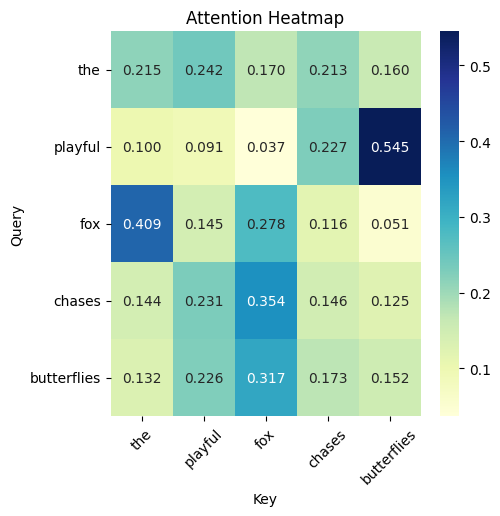

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

def plot_attention_heatmap(tokens, attn_weights):
    attn = attn_weights.detach().cpu()
    T = len(tokens)
    
    plt.figure(figsize=(T, T))
    sns.heatmap(
        attn,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="YlGnBu",
        annot=True,
        fmt=".3f",
        cbar=True)

    plt.xlabel("Key")
    plt.ylabel("Query")
    plt.title("Attention Heatmap")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

## YOUR SOLUTION HERE ##
plot_attention_heatmap(tokens, attn_weights)
plt.show()

How would you interpret the attention weights for the token `fox`? That is, how much does the token `fox` (as the Query) attend to each token in the sequence (as Keys)?

<details><summary style="display:list-item; font-size:16px; color:blue;">Interpretation</summary>

We should remember that the attention scores and weights were computed using **randomly initialized** values for both the embeddings and weight matrices. 

Therefore, these numbers **do not correspond** to any meaningful values until training. 

But if we pretend that these values were meaningful, we would say that:
- `fox` pays the strongest attention to `the` (0.4089), meaning that ~41% of its attention goes to `the`.
- `fox` pays the least attention to `butterflies` (0.051).

</details>

The token “fox”, acting as the Query, assigns the highest attention weight to “the”, followed by itself (“fox”), meaning these tokens contribute the most to constructing the contextual representation of “fox”.  